##**OCR Text Extraction Tool**

In [ ]:
pip install opencv-python pytesseract pillow

In [ ]:
import cv2
import pytesseract
import re
import json
from PIL import Image
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [ ]:
IMAGE_PATH = "input3.png"

RAW IMAGE


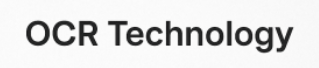

In [ ]:
raw = cv2.imread("input3.png")
print("RAW IMAGE")
cv2_imshow(raw)

In [ ]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # enlarge image
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # threshold
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 2
    )

    return thresh


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
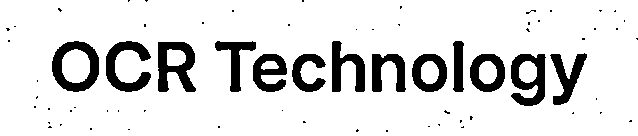

In [ ]:
preprocess_image("input3.png")

In [ ]:
def extract_text(processed_img):
    text = pytesseract.image_to_string(processed_img)
    return text

In [ ]:
def clean_text(text):
    # remove special characters except basic punctuation
    text = re.sub(r"[^a-zA-Z0-9.,:\n ]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
def convert_to_json(text):
    lines = text.split(":")
    data = {}

    if len(lines) >= 2:
        key = lines[0].strip()
        value = lines[1].strip()
        data[key] = value
    else:
        data["text"] = text

    return data

In [ ]:
def main():
    print("Processing image...")

    processed_img = preprocess_image(IMAGE_PATH)

    raw_text = extract_text(processed_img)
    print("\nRaw Text:\n", raw_text)

    cleaned = clean_text(raw_text)
    print("\nCleaned Text:\n", cleaned)

    structured_data = convert_to_json(cleaned)

    # save txt
    with open("output.txt", "w", encoding="utf-8") as f:
        f.write(cleaned)

    # save json
    with open("output.json", "w", encoding="utf-8") as f:
        json.dump(structured_data, f, indent=4)

    print("\nOutput saved as output.txt and output.json")


In [ ]:
if __name__ == "__main__":
    main()

Processing image...

Raw Text:
 OCR Technology -


Cleaned Text:
 OCR Technology

Output saved as output.txt and output.json
